# Question Answering Success Analysis

In this notebook the the performance of the boardgame rulebook question answering system will be analyzed. It loads question-answer results, computes success metrics, and visualizes the results with graphs.

In [10]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

## Load Question Answering Results Data

Load the results data (CSV or JSON) containing ground truth answers and predicted answers. Update the file path as needed.

In [11]:
# Example: Load results from a CSV or JSON file
# Update the file path as needed
results_path = '../data/processed/qa_results.csv'  # or .json

# Try loading CSV, fallback to JSON
try:
    df = pd.read_csv(results_path)
except Exception:
    df = pd.read_json(results_path)

df.head()

,question,ground_truth,predicted,overall_score,relevance_score,completeness_score,accuracy_score,conciseness_score,question_type,page,section,chunk_index,best_chunk_rank,answer_source,forum_confidence,rulebook_confidence
0,When do I increase my radiation?,Each time a Stalker slides their Turn token (a...,Do I apply the -4 to every instance I would in...,0.835520,0.812985,1.00,0.750000,0.8325,procedural,NaN,Radiation,NaN,10.0,rulebook,0.742209,0.663489
1,How do I win the mission?,Each Mission has a main Objective card which s...,My copy is missing A B C D E tokens for Missio...,0.629721,0.612405,1.00,0.364999,1.0000,procedural,NaN,Miscellaneous,NaN,22.0,rulebook,0.593520,0.585337
2,How many players can play this game?,This game can be played by 1-4 players.,Does it stack with Laser Sight's (Attachment) ...,0.339734,0.123245,0.75,0.200026,0.7050,procedural,NaN,Weapons and Attacks,NaN,6.0,rulebook,0.557826,0.605058
3,How does movement work?,"On your turn, when you use the Move action, yo...",During a Movement an Enemy entered a space wit...,0.814259,0.714198,1.00,0.750000,1.0000,procedural,NaN,Enemies,NaN,NaN,rulebook,0.533837,0.639163
4,How do I perform an attack action?,Choose an Attack Action and a valid Target. - ...,Should I immediately rotate that enemy to face...,0.743851,0.934187,1.00,0.442113,0.7350,procedural,NaN,Enemies,NaN,NaN,rulebook,0.588142,0.685938


## Preprocess and Explore Data

Clean and preprocess the data, handle missing values, and display basic statistics about the dataset.

In [12]:
# Drop rows with missing values in essential columns only
clean_df = df.dropna(subset=['question', 'ground_truth', 'predicted'])

# Show basic statistics
print('Number of questions:', len(clean_df))
print('Columns:', clean_df.columns.tolist())
clean_df.describe(include='all')

Number of questions: 40
Columns: ['question', 'ground_truth', 'predicted', 'overall_score', 'relevance_score', 'completeness_score', 'accuracy_score', 'conciseness_score', 'question_type', 'page', 'section', 'chunk_index', 'best_chunk_rank', 'answer_source', 'forum_confidence', 'rulebook_confidence']


,question,ground_truth,predicted,overall_score,relevance_score,completeness_score,accuracy_score,conciseness_score,question_type,page,section,chunk_index,best_chunk_rank,answer_source,forum_confidence,rulebook_confidence
count,40,40,40,40.000000,40.000000,40.000000,40.000000,40.000000,40,3.000000,25,3.000000,15.000000,40,40.000000,40.000000
unique,40,40,39,NaN,NaN,NaN,NaN,NaN,5,NaN,7,NaN,NaN,2,NaN,NaN
top,When do I increase my radiation?,Each time a Stalker slides their Turn token (a...,"You do not. And when equipping an artifact, un...",NaN,NaN,NaN,NaN,NaN,procedural,NaN,Enemies,NaN,NaN,rulebook,NaN,NaN
freq,1,1,2,NaN,NaN,NaN,NaN,NaN,23,NaN,13,NaN,NaN,25,NaN,NaN
mean,NaN,NaN,NaN,0.677118,0.582917,0.859018,0.616484,0.817908,NaN,17.666667,NaN,74.666667,8.800000,NaN,0.776774,0.672967
std,NaN,NaN,NaN,0.207821,0.305688,0.160624,0.344491,0.259835,NaN,0.577350,NaN,0.577350,7.002041,NaN,0.167237,0.180957
min,NaN,NaN,NaN,0.185248,0.023869,0.500000,0.065713,0.140000,NaN,17.000000,NaN,74.000000,1.000000,NaN,0.482481,0.059656
25%,NaN,NaN,NaN,0.548896,0.258961,0.750000,0.235710,0.773125,NaN,17.500000,NaN,74.500000,2.500000,NaN,0.597522,0.594514
50%,NaN,NaN,NaN,0.718186,0.686658,0.906818,0.750000,0.924000,NaN,18.000000,NaN,75.000000,8.000000,NaN,0.834610,0.668434
75%,NaN,NaN,NaN,0.843789,0.814198,1.000000,0.925275,1.000000,NaN,18.000000,NaN,75.000000,11.500000,NaN,0.888270,0.769488


## Calculate Success Metrics Using Similarity

Compute and visualize fuzzy string similarity (token set ratio) for the question answering results. This provides a more realistic measure of model performance for free-form answers.

## Multi-Dimensional Scoring Analysis (if available)

If the results include multi-dimensional scores, display breakdown by dimension.

Multi-Dimensional Scoring Results
Overall Score:      67.71%
  Relevance (35%):  58.29%
  Completeness (30%): 85.90%
  Accuracy (25%):   61.65%
  Conciseness (10%): 81.79%

Passing (≥80%):     14/40


C:\Users\I544554\AppData\Local\Temp\ipykernel_31440\1012239527.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dimension_data.values(), labels=dimension_data.keys())


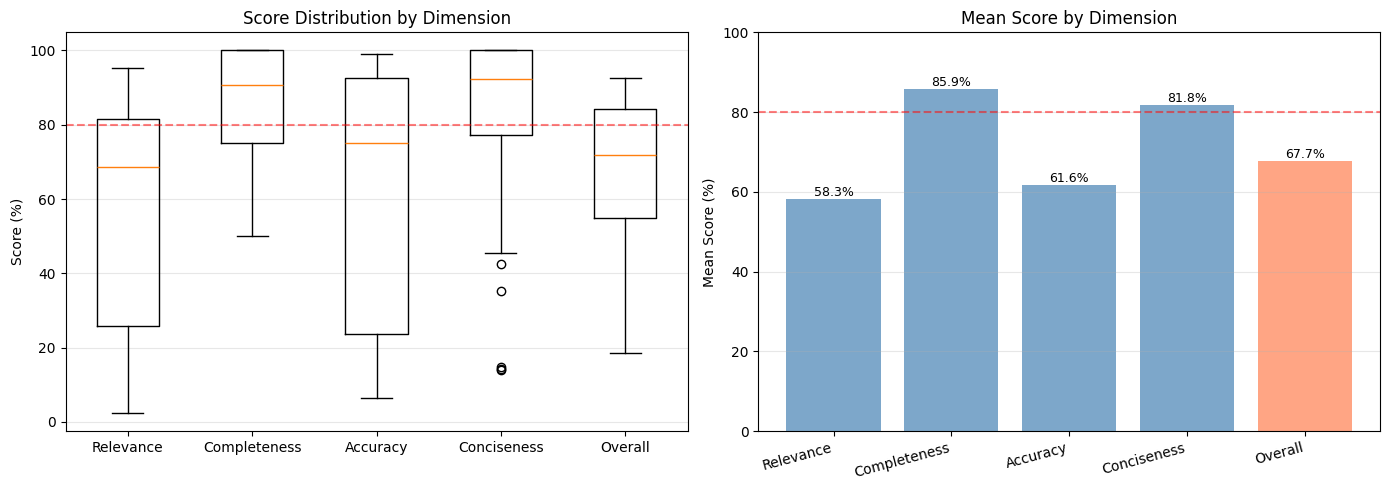

In [13]:
# Check if multi-dimensional scores are available
multidim_cols = ['overall_score', 'relevance_score', 'completeness_score', 'accuracy_score', 'conciseness_score']

if all(col in clean_df.columns for col in multidim_cols):
    print("Multi-Dimensional Scoring Results")
    print("="*70)
    print(f"Overall Score:      {clean_df['overall_score'].mean():.2%}")
    print(f"  Relevance (35%):  {clean_df['relevance_score'].mean():.2%}")
    print(f"  Completeness (30%): {clean_df['completeness_score'].mean():.2%}")
    print(f"  Accuracy (25%):   {clean_df['accuracy_score'].mean():.2%}")
    print(f"  Conciseness (10%): {clean_df['conciseness_score'].mean():.2%}")
    print(f"\nPassing (≥80%):     {(clean_df['overall_score'] >= 0.8).sum()}/{len(clean_df)}")
    print("="*70)
    
    # Visualize dimension breakdown
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot of all dimensions
    ax = axes[0]
    dimension_data = {
        'Relevance': clean_df['relevance_score'] * 100,
        'Completeness': clean_df['completeness_score'] * 100,
        'Accuracy': clean_df['accuracy_score'] * 100,
        'Conciseness': clean_df['conciseness_score'] * 100,
        'Overall': clean_df['overall_score'] * 100
    }
    ax.boxplot(dimension_data.values(), labels=dimension_data.keys())
    ax.set_ylabel('Score (%)')
    ax.set_title('Score Distribution by Dimension')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
    
    # Bar plot of mean scores
    ax = axes[1]
    means = [v.mean() for v in dimension_data.values()]
    colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue', 'coral']
    bars = ax.bar(dimension_data.keys(), means, color=colors, alpha=0.7)
    ax.set_ylabel('Mean Score (%)')
    ax.set_title('Mean Score by Dimension')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=80, color='red', linestyle='--', alpha=0.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)
    
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Multi-dimensional scores not available in this dataset")
    print("Available columns:", clean_df.columns.tolist())


Using multi-dimensional overall_score from CSV (0-100 scale)
Mean similarity: 67.71
Questions passing threshold: 14/40


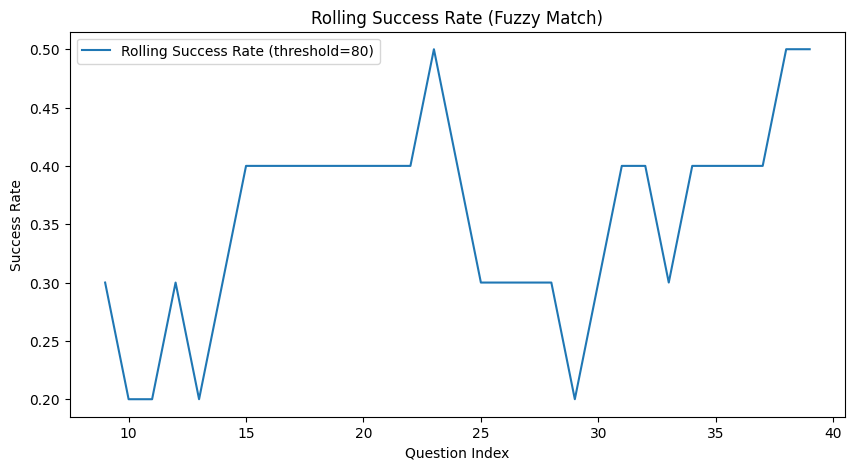

In [14]:
# Define threshold for fuzzy match success
threshold = 80

# Handle different score column formats from QA batch runs
if 'overall_score' in clean_df.columns:
    # Multi-dimensional scoring format (0-1 scale) - USE THIS for new runs
    clean_df['similarity'] = clean_df['overall_score'] * 100
    print('Using multi-dimensional overall_score from CSV (0-100 scale)')
elif 'score' in clean_df.columns and 'similarity' not in clean_df.columns:
    # Old single-score format (0-1 scale)
    clean_df['similarity'] = clean_df['score'] * 100
    print('Using pre-computed similarity scores from CSV (old format)')
elif 'similarity' not in clean_df.columns:
    # Fallback: compute text similarity if not present
    try:
        from rapidfuzz import fuzz
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
        from rapidfuzz import fuzz
    similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(clean_df['ground_truth'], clean_df['predicted'])]
    clean_df['similarity'] = similarities
    print('Computed text similarity scores using rapidfuzz (fallback)')

clean_df['correct'] = clean_df['similarity'] >= threshold

print(f'Mean similarity: {clean_df["similarity"].mean():.2f}')
print(f'Questions passing threshold: {clean_df["correct"].sum()}/{len(clean_df)}')

# Rolling success rate
window = 10
rolling_success = clean_df['correct'].rolling(window).mean()
plt.figure(figsize=(10,5))
plt.plot(rolling_success, label=f'Rolling Success Rate (threshold={threshold})')
plt.xlabel('Question Index')
plt.ylabel('Success Rate')
plt.title('Rolling Success Rate (Fuzzy Match)')
plt.legend()
plt.show()


## Fuzzy String Similarity Analysis

Since exact string match metrics are too strict for free-form answers, we use fuzzy string similarity to better gauge answer quality.

Mean similarity: 67.71


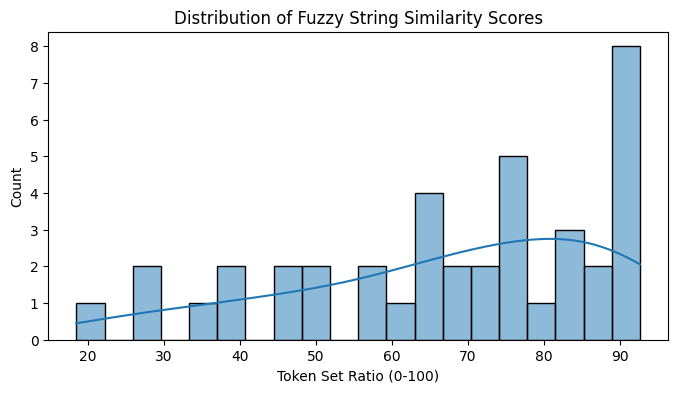

In [15]:
# Use the similarity scores already computed in the previous cell
similarities = clean_df['similarity'].tolist()

print(f'Mean similarity: {np.mean(similarities):.2f}')
plt.figure(figsize=(8,4))
sns.histplot(similarities, bins=20, kde=True)
plt.title('Distribution of Fuzzy String Similarity Scores')
plt.xlabel('Token Set Ratio (0-100)')
plt.ylabel('Count')
plt.show()

## Fuzzy Match Confusion Matrix

We treat predictions as correct if their similarity is above the threshold, and plot a confusion matrix.

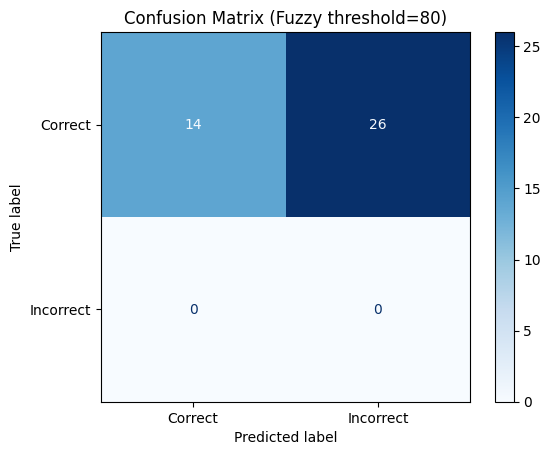

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True: all answers are expected to be correct (since each row is a QA pair)
y_true_bin = np.ones(len(clean_df), dtype=int)
y_pred_bin = clean_df['correct'].astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'Incorrect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Fuzzy threshold={threshold})')
plt.show()

## Visualize Success Rate Over Time (Fuzzy Match)

We define a prediction as 'correct' if its similarity to the ground truth is above a threshold (e.g., 80).

Found 193 valid archive files


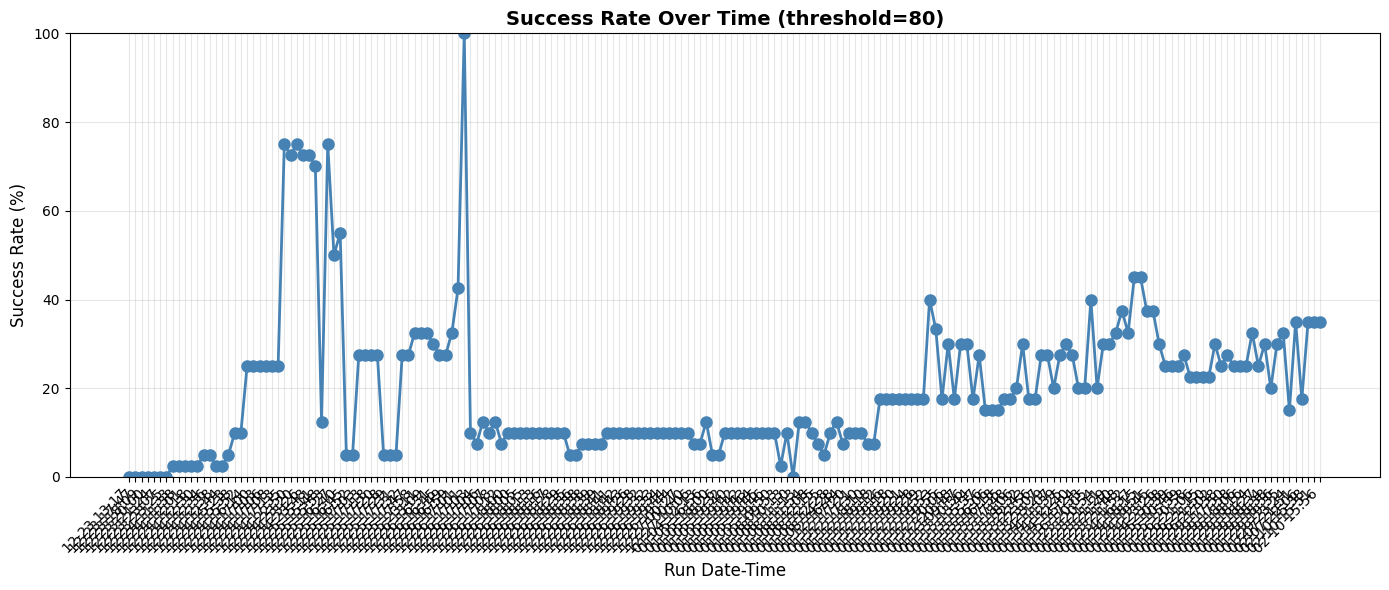


Success rate range: 0.0% to 100.0%
Latest success rate: 35.0%


In [1]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Find all archived qa_results files
archive_files = sorted(glob.glob('../data/processed/archive/qa_results_*.csv'))

# Extract datetime from filename
pattern = re.compile(r'qa_results_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_\d+s')

def extract_dt(fname):
    match = pattern.search(fname)
    if match:
        return match.group(1)
    return None

# Filter and sort by datetime
valid_files = []
for f in archive_files:
    dt_str = extract_dt(f)
    if dt_str:
        valid_files.append((f, dt_str))

valid_files = sorted(valid_files, key=lambda x: x[1])

success_rates = []
datetimes = []
file_labels = []
threshold = 80

print(f"Found {len(valid_files)} valid archive files")

for f, dt in valid_files:
    try:
        df = pd.read_csv(f)
        
        # Handle different score column formats
        if 'overall_score' in df.columns:
            # Multi-dimensional scoring format (0-1 scale)
            similarity_scores = df['overall_score'] * 100
        elif 'score' in df.columns:
            # Old format with single score (0-1 scale)
            similarity_scores = df['score'] * 100
        elif 'similarity' in df.columns:
            # Already computed similarity
            similarity_scores = df['similarity']
        else:
            # Compute similarity if not present
            try:
                from rapidfuzz import fuzz
                similarity_scores = [fuzz.token_set_ratio(str(gt), str(pred)) 
                                   for gt, pred in zip(df['ground_truth'], df['predicted'])]
            except:
                print(f"Skipping {f}: cannot compute similarity")
                continue
        
        correct = (pd.Series(similarity_scores) >= threshold).mean()
        success_rates.append(correct * 100)  # Convert to percentage
        datetimes.append(dt)
        
        # Create short label from datetime
        dt_obj = datetime.strptime(dt, '%Y-%m-%d_%H-%M-%S')
        file_labels.append(dt_obj.strftime('%m-%d %H:%M'))
    except Exception as e:
        print(f"Error processing {f}: {e}")

if not success_rates:
    print("No valid data found to plot")
else:
    plt.figure(figsize=(14, 6))
    plt.plot(range(len(success_rates)), success_rates, marker='o', linewidth=2, markersize=8, color='steelblue')
    
    plt.xticks(range(len(success_rates)), file_labels, rotation=45, ha='right')
    plt.xlabel('Run Date-Time', fontsize=12)
    plt.ylabel('Success Rate (%)', fontsize=12)
    plt.title(f'Success Rate Over Time (threshold={threshold})', fontsize=14, fontweight='bold')
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nSuccess rate range: {min(success_rates):.1f}% to {max(success_rates):.1f}%")
    print(f"Latest success rate: {success_rates[-1]:.1f}%")
